# 10. Data Pipeline Automation
## 📚 Learning Objectives

By completing this notebook, you will:
- Build automated data processing pipelines
- Know how such pipelines are scheduled and orchestrated in production (concepts + pointers)
- Handle errors and retries in pipelines
- Track pipeline execution: duration, success/failure
- Automate repetitive data tasks

## 🔗 Where this fits

**Builds on:** Course 05 — Unit 5, lessons 05 and 09 (pipelines and monitoring) — automation is what closes the loop between the two.

**Used later in:** Course 11 (AIAT 125) — Unit 5, lesson 02, whose automated retraining pipeline is this idea applied to a model.

---

## The Story: From Manual to Automatic

Imagine you have a task you do daily (manual pipeline). **Before** automation, you do it manually every day. **After** automation, it runs automatically - saves time, reduces errors!

Same with data pipelines: **After** building pipelines, we automate - schedule runs, handle errors, monitor execution. **After** automation, pipelines run reliably!

---

## Why Pipeline Automation Matters

Pipeline automation is essential because:
- **Efficiency**: Saves time on repetitive tasks
- **Reliability**: Reduces human errors
- **Scalability**: Handles large workloads
- **Production**: Essential for production systems

**Common Student Questions:**
- **Q: What should I automate?**
  - Answer: Repetitive tasks, regular data processing, model retraining
  - Example: Daily data updates, weekly model retraining
  - Rule: If you do it regularly, automate it!
  
- **Q: How do I handle errors in automated pipelines?**
  - Answer: Use try/except, logging, retries, alerts
  - Example: Retry failed steps, log errors, send alerts
  - Benefit: Pipelines continue even when errors occur

---

## Introduction

**Data pipeline automation** transforms manual data processing into automated, scheduled workflows. This ensures reliable, efficient data processing in production environments.


## 🎯 The case: the scheduler Airbnb wrote because cron was not enough

In **October 2014** Maxime Beauchemin, then at Airbnb, started **Apache Airflow**. The
company's data work had outgrown what a list of cron entries could express: jobs depended on
other jobs, a failure halfway through needed to resume rather than restart, and when a
number looked wrong at 9 a.m. somebody had to be able to see which run produced it. Airflow's
answer was to make the pipeline a **directed acyclic graph of tasks** with a run history you
can inspect. It entered the Apache Incubator in March 2016 and became a top-level Apache
project in **January 2019**; it is now the default orchestration layer across the industry.

**What goes wrong without automation.** A manual pipeline fails in three specific ways, and
none of them announce themselves:

1. **Skipped runs.** Nobody ran Tuesday's job. The dashboard shows Monday's numbers and looks
   perfectly healthy.
2. **Silent partial failure.** Extract worked, transform crashed, load wrote yesterday's
   file again. Downstream consumers see plausible data.
3. **No provenance.** Six months later, a number is disputed and nobody can say which run,
   which code, or which input produced it.

The extract → transform → load run below takes **0.03 seconds** on **20,000 real 911
records**. The value is not the speed. It is that the run is **named, timed, logged, and
repeatable** — including the honest detail that **2,466 records had no ZIP code and were
flagged rather than dropped**.


**All concepts are explained in the code comments below - you can learn everything from this notebook alone!**

---

## 🔗 Automating Data Workflows

**Manual data processing is slow and error-prone!**
- Processing data manually takes too much time
- Errors happen when steps are forgotten
- We need automated, reliable pipelines

**This notebook teaches pipeline automation!**
- We'll learn **pipeline design** - structure data workflows
- We'll see **how scheduling works** - cron/Airflow concepts and pointers (the pipeline here runs once, by hand)
- We'll learn **error handling** - make pipelines robust
- We'll learn **monitoring** - track pipeline health

**This enables production-ready data pipelines!**

---

## Learning Objectives
1. Design automated data processing pipelines
2. Implement error handling and retries
3. Know how pipeline scheduling works in production (cron, Airflow - concepts + pointers)
4. Track pipeline runs: duration, success/failure

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- **Real data:** `montgomery_911_calls.csv` — the extract step reads a real slice
  of the 911 dispatch log (as a scheduled job would read yesterday's records),
  including its genuinely missing ZIP codes.
- Pipeline structure, error handling, run logging

**Outputs:** What you'll see when you run the cells

- One extract → transform → load run, with a run-log entry and timing

---


In [1]:
# WHAT: Import libraries and preview the automation topics.
# WHY: Pipelines that run themselves need explicit structure: steps, error handling, and run logs.

# Step 1: Import libraries
import pandas as pd
import numpy as np
from datetime import datetime
import time

print("✅ Libraries imported!")
print("\n📚 This notebook covers:")
print("   - Pipeline design")
print("   - Error handling")
print("   - Pipeline monitoring")
print("   - Automation strategies")

✅ Libraries imported!

📚 This notebook covers:
   - Pipeline design
   - Error handling
   - Pipeline monitoring
   - Automation strategies


## Step 2: Define Pipeline Steps

We define three functions: **extract** (read the source), **transform** (clean and
enrich it), **load** (write it onward). The extract step reads a real slice of the
Montgomery County 911 dispatch log — the same shape of job a nightly scheduler
would run against yesterday's records.


In [2]:
# WHAT: Define the three ETL steps - extract reads REAL source records, transform cleans them, load writes them on.
# WHY: Naming the steps as functions is what makes a pipeline schedulable, testable and restartable.

DATA_DIR = '../../../Course 04/datasets/raw/'

# Extract: get data from source
def step1_extract():
    """Read a slice of the real 911 dispatch log, as a nightly job would."""
    data = pd.read_csv(DATA_DIR + 'montgomery_911_calls.csv',
                       usecols=['lat', 'lng', 'zip', 'title', 'timeStamp', 'twp'],
                       nrows=20_000, parse_dates=['timeStamp'])
    return data

# Transform: process and clean
def step2_transform(data):
    """Clean and enrich: split the call type, flag night calls, normalise a numeric column."""
    data = data.copy()
    data['service'] = data['title'].str.split(':').str[0]
    data['hour'] = data['timeStamp'].dt.hour
    data['is_night'] = (data['hour'] < 6) | (data['hour'] >= 22)
    # Real gaps: 'zip' is missing for some calls. A pipeline must decide - and log it.
    n_missing_zip = int(data['zip'].isna().sum())
    data['zip_missing'] = data['zip'].isna()
    data['lat_normalized'] = (data['lat'] - data['lat'].mean()) / data['lat'].std()
    data.attrs['n_missing_zip'] = n_missing_zip
    return data

# Load: save to destination (simulated)
def step3_load(data):
    """In production: write to a database, warehouse or object store."""
    summary = data.groupby('service').size().to_dict()
    return summary

print("✅ Pipeline steps defined!")
print("   - Extract: read 20,000 real 911 records from the dispatch log")
print("   - Transform: derive service/hour/is_night, flag missing ZIPs, normalise lat")
print("   - Load: aggregate and hand off (a real job would write to storage)")

✅ Pipeline steps defined!
   - Extract: read 20,000 real 911 records from the dispatch log
   - Transform: derive service/hour/is_night, flag missing ZIPs, normalise lat
   - Load: aggregate and hand off (a real job would write to storage)


## Step 3: Execute Pipeline
Execute complete pipeline with error handling.


In [3]:
# WHAT: Chain extract -> transform -> load in run_pipeline() with try/except and a run log.
# WHY: The ETL wrapper turns loose scripts into a schedulable unit that reports success or failure.

print("\n" + "=" * 70)
print("Running the Pipeline")
print("=" * 70)

def run_pipeline():
    try:
        start_time = datetime.now()
        print(f"\n🚀 Starting pipeline at {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
        # Extract
        data = step1_extract()
        print(f"   Extract: {len(data):,} records read "
              f"({data['timeStamp'].min():%Y-%m-%d} to {data['timeStamp'].max():%Y-%m-%d})")
        # Transform
        data = step2_transform(data)
        print(f"   Transform: {data.shape[1]} columns out; "
              f"{data.attrs['n_missing_zip']:,} records had no ZIP code (real gaps, flagged not dropped)")
        # Load
        summary = step3_load(data)
        print(f"   Load: handed off {sum(summary.values()):,} records -> {summary}")
        end_time = datetime.now()
        duration = (end_time - start_time).total_seconds()
        print(f"\n✅ Pipeline completed successfully!")
        print(f"   Duration: {duration:.2f} seconds")
        return True
    except Exception as e:
        print(f"\n❌ Pipeline failed: {str(e)}")
        return False

# Run pipeline and record a small run log (the seed of monitoring)
run_started = datetime.now()
success = run_pipeline()
run_log = {
    'run_at': run_started.strftime('%Y-%m-%d %H:%M:%S'),
    'status': 'success' if success else 'failed',
    'duration_s': round((datetime.now() - run_started).total_seconds(), 2),
}
print(f"\n📒 Run log entry: {run_log}")
print("   In production this entry would be appended to a log store, and an")
print("   alert raised whenever status != success.")

print("""
💡 Scheduling & orchestration (how this runs WITHOUT a human):
   - cron / Task Scheduler: run `python pipeline.py` daily or hourly
   - Airflow / Prefect / Dagster: DAGs with retries, backfills, and alerting
   This notebook ran the pipeline once by hand; wiring it into one of the
   schedulers above is exactly how the same code becomes an automated job.""")

print("\n" + "=" * 70)
print("🎉 Example 10 complete - and with it, Course 05!")
print("=" * 70)


Running the Pipeline

🚀 Starting pipeline at 2026-08-31 01:09:19
   Extract: 20,000 records read (2015-12-10 to 2016-01-29)
   Transform: 11 columns out; 2,466 records had no ZIP code (real gaps, flagged not dropped)
   Load: handed off 20,000 records -> {'EMS': 9449, 'Fire': 2870, 'Traffic': 7681}

✅ Pipeline completed successfully!
   Duration: 0.03 seconds

📒 Run log entry: {'run_at': '2026-08-31 01:09:19', 'status': 'success', 'duration_s': 0.03}
   In production this entry would be appended to a log store, and an
   alert raised whenever status != success.

💡 Scheduling & orchestration (how this runs WITHOUT a human):
   - cron / Task Scheduler: run `python pipeline.py` daily or hourly
   - Airflow / Prefect / Dagster: DAGs with retries, backfills, and alerting
   This notebook ran the pipeline once by hand; wiring it into one of the
   schedulers above is exactly how the same code becomes an automated job.

🎉 Example 10 complete - and with it, Course 05!


## Step 4: One run tells you nothing — run it 51 times

The run above succeeded. So would a run that processed three rows, or yesterday's rows again.
The only way to see that is to compare a run against the runs before it, which is what a
scheduler's history gives you and a bare script does not. So let us actually build one: take the
same `step1_extract → step2_transform → step3_load` functions and execute them **once per
calendar day** in the extracted slice, exactly as a nightly job would have.

51 nightly runs replayed, 51 returned status='success', 0 raised an exception.
Volume assertion: 196 to 586 rows (median 391 +/- 50%)
Runs that would have FAILED that assertion while reporting success: 4
       day  rows_loaded  missing_zip_pct  status
2015-12-10          114             12.3 success
2016-01-23          887              9.7 success
2016-01-24          657             10.4 success
2016-01-29           35              8.6 success


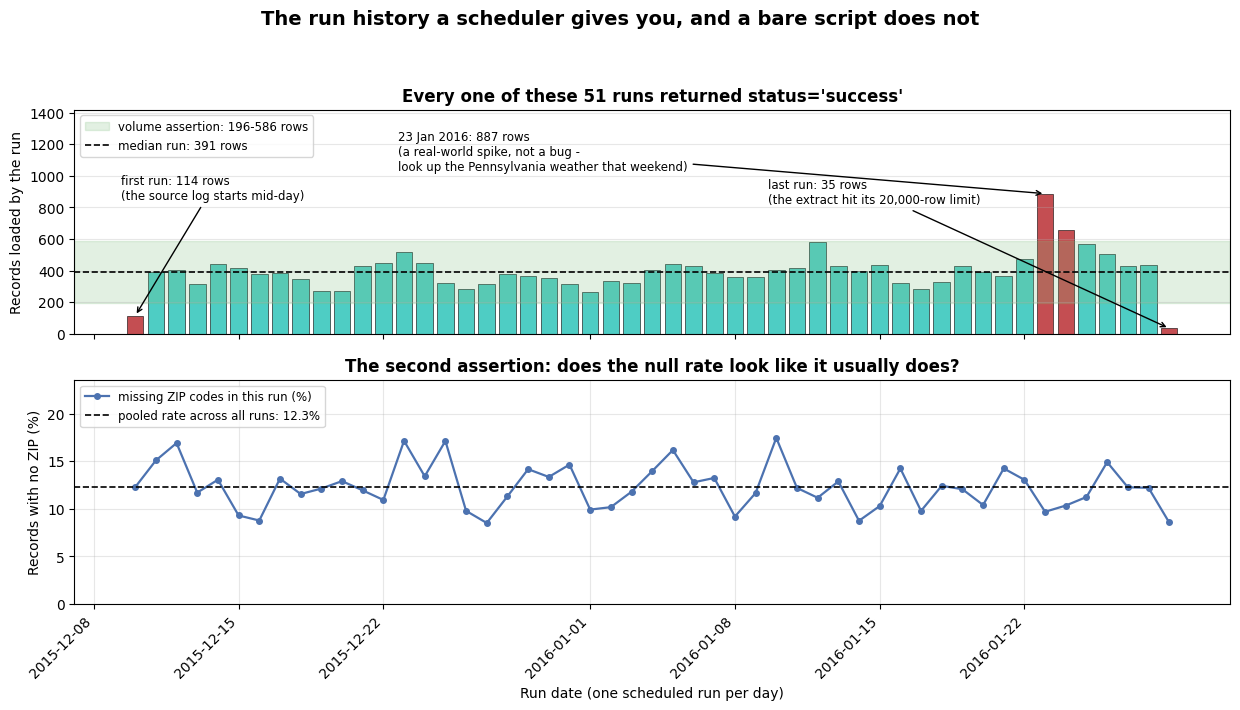


Null rate across the 51 runs: 8.5% to 17.5%, pooled 12.3%.
Pick your alert threshold from a picture like this one, BEFORE the night it fires.


In [4]:
# WHAT: Execute the real pipeline functions once per calendar day, keep a run log, and plot it.
# WHY: "Silent success" is the failure mode that matters: every run below returns success, and
#      some of them are wrong. A run history with volume and null-rate assertions is what turns
#      an invisible problem into a visible one.

import matplotlib.pyplot as plt

raw = step1_extract()                      # the same extract step, one read
raw['day'] = raw['timeStamp'].dt.date

runs = []
for day, day_slice in raw.groupby('day'):  # one "nightly run" per calendar day
    t0 = time.perf_counter()
    try:
        transformed = step2_transform(day_slice)
        summary = step3_load(transformed)
        status = 'success'
    except Exception as exc:               # a real pipeline logs which step failed
        transformed, summary, status = None, {}, f'failed: {exc}'
    runs.append({
        'day': pd.Timestamp(day),
        'rows_loaded': 0 if transformed is None else int(sum(summary.values())),
        'missing_zip_pct': None if transformed is None
                           else 100 * transformed['zip_missing'].mean(),
        'duration_ms': (time.perf_counter() - t0) * 1000,
        'status': status,
    })
run_history = pd.DataFrame(runs)

# The assertion nobody writes: expected volume. We pick the band from the observed
# history - median row count, plus or minus 50%.
median_rows = run_history['rows_loaded'].median()
lo, hi = 0.5 * median_rows, 1.5 * median_rows
run_history['volume_ok'] = run_history['rows_loaded'].between(lo, hi)
flagged = run_history[~run_history['volume_ok']]

print(f"{len(run_history)} nightly runs replayed, "
      f"{(run_history['status'] == 'success').sum()} returned status='success', "
      f"{(run_history['status'] != 'success').sum()} raised an exception.")
print(f"Volume assertion: {lo:,.0f} to {hi:,.0f} rows (median {median_rows:,.0f} +/- 50%)")
print(f"Runs that would have FAILED that assertion while reporting success: {len(flagged)}")
print(flagged[['day', 'rows_loaded', 'missing_zip_pct', 'status']]
      .assign(day=lambda d: d['day'].dt.strftime('%Y-%m-%d'),
              missing_zip_pct=lambda d: d['missing_zip_pct'].round(1))
      .to_string(index=False))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12.5, 7.2), sharex=True)

# --- TOP: rows loaded per run, against the volume assertion ---
colours = ['#4ECDC4' if ok else '#C44E52' for ok in run_history['volume_ok']]
ax1.bar(run_history['day'], run_history['rows_loaded'], color=colours,
        edgecolor='black', linewidth=0.4, width=0.8)
ax1.axhspan(lo, hi, color='#7FBF7F', alpha=0.22,
            label=f'volume assertion: {lo:,.0f}-{hi:,.0f} rows')
ax1.axhline(median_rows, ls='--', color='black', lw=1.2,
            label=f'median run: {median_rows:,.0f} rows')
first, last = run_history.iloc[0], run_history.iloc[-1]
peak = run_history.loc[run_history['rows_loaded'].idxmax()]
# Annotations are placed in axes coordinates so they never land on a bar or the legend.
ax1.annotate(f"first run: {first['rows_loaded']} rows\n(the source log starts mid-day)",
             xy=(first['day'], first['rows_loaded']), xycoords='data',
             xytext=(0.04, 0.60), textcoords='axes fraction', fontsize=8.5, ha='left',
             arrowprops=dict(arrowstyle='->', lw=1))
ax1.annotate(f"{peak['day']:%d %b %Y}: {peak['rows_loaded']} rows\n"
             f"(a real-world spike, not a bug -\nlook up the Pennsylvania weather that weekend)",
             xy=(peak['day'], peak['rows_loaded']), xycoords='data',
             xytext=(0.28, 0.73), textcoords='axes fraction', fontsize=8.5, ha='left',
             arrowprops=dict(arrowstyle='->', lw=1))
ax1.annotate(f"last run: {last['rows_loaded']} rows\n(the extract hit its 20,000-row limit)",
             xy=(last['day'], last['rows_loaded']), xycoords='data',
             xytext=(0.60, 0.58), textcoords='axes fraction', fontsize=8.5, ha='left',
             arrowprops=dict(arrowstyle='->', lw=1))
ax1.set_ylim(0, run_history['rows_loaded'].max() * 1.60)
ax1.set_ylabel('Records loaded by the run')
ax1.set_title(f"Every one of these {len(run_history)} runs returned status='success'",
              fontsize=12, weight='bold')
ax1.legend(fontsize=8.5, loc='upper left')
ax1.grid(axis='y', alpha=0.3)

# --- BOTTOM: the data-quality number the transform already computes ---
pooled = 100 * raw['zip'].isna().mean()
ax2.plot(run_history['day'], run_history['missing_zip_pct'], marker='o', ms=4,
         color='#4C72B0', lw=1.6, label='missing ZIP codes in this run (%)')
ax2.axhline(pooled, ls='--', color='black', lw=1.2,
            label=f'pooled rate across all runs: {pooled:.1f}%')
ax2.set_ylabel('Records with no ZIP (%)')
ax2.set_xlabel('Run date (one scheduled run per day)')
ax2.set_ylim(0, run_history['missing_zip_pct'].max() * 1.35)
ax2.set_title('The second assertion: does the null rate look like it usually does?',
              fontsize=12, weight='bold')
ax2.legend(fontsize=8.5, loc='upper left')
ax2.grid(alpha=0.3)

fig.suptitle('The run history a scheduler gives you, and a bare script does not',
             fontsize=14, weight='bold')
fig.autofmt_xdate(rotation=45)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

print(f"\nNull rate across the {len(run_history)} runs: "
      f"{run_history['missing_zip_pct'].min():.1f}% to "
      f"{run_history['missing_zip_pct'].max():.1f}%, pooled {pooled:.1f}%.")
print("Pick your alert threshold from a picture like this one, BEFORE the night it fires.")

**Read the figure.** *Top:* one bar per nightly run, 51 of them, each produced by the same three
functions you defined above. The green band is the volume assertion — the median run plus or
minus 50% — and the four red bars are the runs that fall outside it. Every bar, red ones
included, came back `status='success'`, which is the entire point: a `try/except` only sees
exceptions, and none of these raised one.

The three annotated runs show that a failed assertion is a *question*, not a verdict. The first
run is short because the source log simply begins mid-day; the last is short because the extract
stops at its 20,000-row limit, so the day was cut in half — a genuinely partial load that would
have been published as complete. The tallest bar is neither: it is a real surge in emergency
calls on a specific weekend, and the correct response there is to acknowledge the alert, not to
widen the band.

*Bottom:* the other number worth asserting on — the share of records arriving with no ZIP code,
which the transform step already computes. It wanders in a fairly narrow range around the pooled
rate printed under the plot, and that observed spread is what you use to choose a threshold —
which is exactly what question 1 in the discussion asks you to do.

## ⚠️ Where this breaks

- **This pipeline runs once, by hand.** It has structure, logging and error handling, and it
  has **no scheduler, no retries, no dependency graph, no backfill and no alerting**. Those
  are the parts that make automation hard, and they are what cron, Airflow, Prefect and
  Dagster exist for. Do not mistake a well-organised script for a production pipeline.
- **Retries require idempotency, and most ETL is not idempotent by default.** If `load`
  appends, running the job twice doubles yesterday's rows — and a scheduler *will* run it
  twice eventually, after a timeout or a manual re-trigger. Write to a partition keyed by
  date, or upsert; never blind-append in a retryable step.
- **`try/except` around the whole pipeline hides *where* it failed.** A single handler that
  logs "pipeline failed" tells you nothing at 3 a.m. Handle per step, record which step,
  and make the failure visible somewhere a human is actually looking.
- **Silent success is the dangerous failure mode.** The worst outcome is not a crash; it is
  a run that completes having processed zero rows, or yesterday's rows again. Assert on
  volume — row counts, date ranges, null rates — and fail the run when they move
  unexpectedly.
- **The assumption that must hold: the upstream source keeps its shape and its schedule.**
  A renamed column, a delayed export, a changed timezone, or a source that publishes late
  will all pass through a pipeline that only checks for exceptions.
- **Schedulers add real operational cost.** Airflow needs a metadata database, a scheduler
  process, workers and someone to upgrade it. For a handful of jobs, `cron` plus a script
  that emails on failure is a legitimate answer that many teams abandon too early.
- **The right threshold is not frequency — it is consequence.** Automate when a missed or
  wrong run would go unnoticed, or when the failure would matter. That is the same
  principle as lesson 09's monitoring: build the machinery for the failures nobody would
  otherwise see.


## 💬 Discuss

The pipeline ran end to end in **0.03 seconds**: extracted 20,000 real records
(2015-12-10 to 2016-01-29), transformed to 11 columns while flagging **2,466 missing ZIP
codes**, and loaded `{'EMS': 9449, 'Fire': 2870, 'Traffic': 7681}`.

1. The transform step **flags** missing ZIPs rather than dropping them. Unit 2 lesson 02
   showed that dropping rows with gaps can bias a dataset badly. Design the alert you would
   attach to that count: what number would make the pipeline fail loudly rather than
   continue, and how did you choose it?
2. A scheduled version of this job runs nightly on "yesterday's records". Describe what
   happens if it runs **twice** for the same day, and what you would change to make that
   harmless. (The property has a name — find it in this notebook's limits section.)
3. This job takes 0.03 seconds and the orchestration around it is longer than the work.
   Argue that the machinery is still worth it — then name a job for which it genuinely is
   not, and say what distinguishes the two.


## 📚 References

1. Sculley, D., Holt, G., Golovin, D., et al. (2015). *Hidden Technical Debt in Machine Learning Systems*. NeurIPS 28. <https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html>
2. Polyzotis, N., Roy, S., Whang, S. E., & Zinkevich, M. (2018). *Data Lifecycle Challenges in Production Machine Learning: A Survey*. ACM SIGMOD Record, 47(2), 17-28. <https://doi.org/10.1145/3299887.3299891>
3. Kreuzberger, D., Kühl, N., & Hirschl, S. (2023). *Machine Learning Operations (MLOps): Overview, Definition, and Architecture*. IEEE Access, 11, 31866-31879. <https://arxiv.org/abs/2205.02302>
4. Eken, B., Pallewatta, S., Tran, N. K., Tosun, A., & Babar, M. A. (2024). *A Multivocal Review of MLOps Practices, Challenges and Open Issues*. arXiv:2406.09737. <https://arxiv.org/abs/2406.09737>
5. Bayram, F., Ahmed, B. S., & Hallin, E. (2025). *End-to-End Data Quality-Driven Framework for Machine Learning in Production Environment*. arXiv:2512.19723. <https://arxiv.org/abs/2512.19723>
